# PART B.ipynb


# Part B - Data Preparation

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load Excel file

df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (5200, 19)

First 5 Rows:


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [8]:
print("Columns in Dataset:\n")

for col in df.columns:
    print(col)

Columns in Dataset:

student_id
age
country_region
device_type
education_background
course_level
course_category
course_start_date
week_of_year
sessions
time_spent_hours
videos_watched
quiz_attempts
assignments_submitted
forum_posts
avg_quiz_score
attendance_rate
completion_status
final_score


In [9]:
df.columns = df.columns.str.strip()

In [10]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Numerical columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64


In [11]:
label_encoders = {}

for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))
    
    label_encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [12]:
print(df.columns.tolist())

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


In [13]:
X_cls = df.drop(columns=['completion_status','final_score'])

y_cls = df['completion_status']

print("Classification Features Shape:", X_cls.shape)
print("Classification Target Shape:", y_cls.shape)

Classification Features Shape: (5200, 17)
Classification Target Shape: (5200,)


In [14]:
X_reg = df.drop(columns=['completion_status','final_score'])

y_reg = df['final_score']

print("Regression Features Shape:", X_reg.shape)
print("Regression Target Shape:", y_reg.shape)

Regression Features Shape: (5200, 17)
Regression Target Shape: (5200,)


In [15]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("X_train_cls:", X_train_cls.shape)
print("X_test_cls :", X_test_cls.shape)

X_train_cls: (4160, 17)
X_test_cls : (1040, 17)


In [16]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)

X_train_reg: (4160, 17)
X_test_reg : (1040, 17)


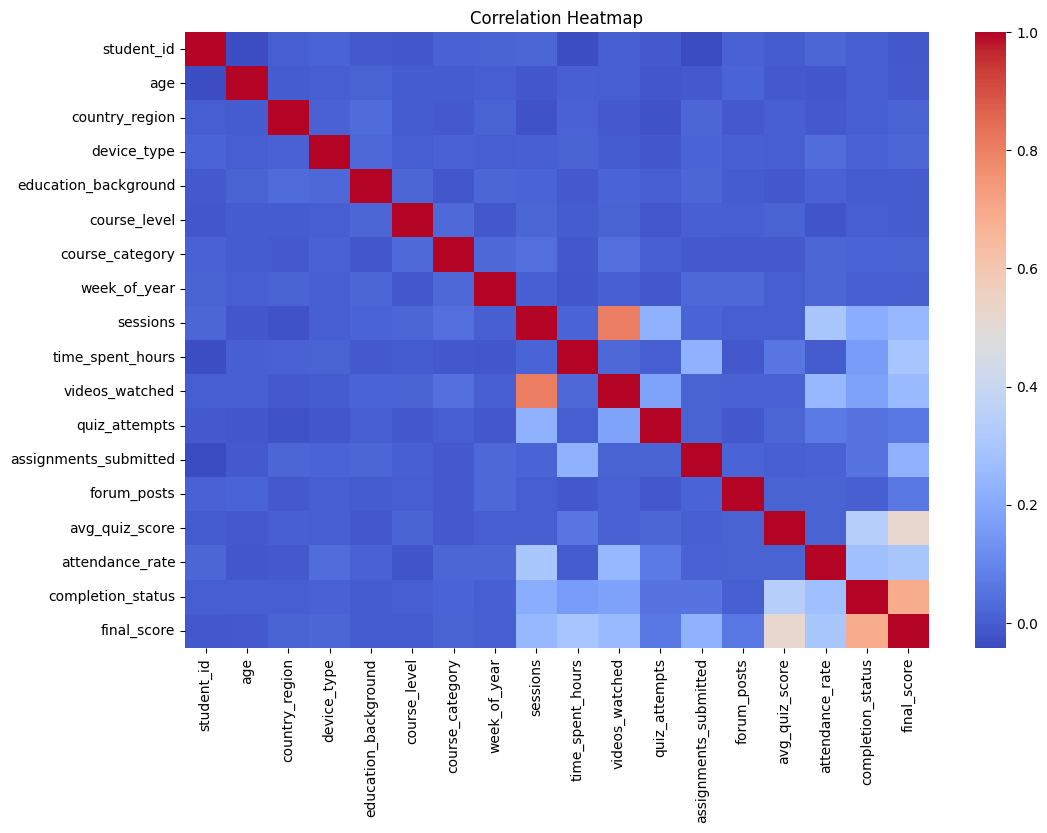

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

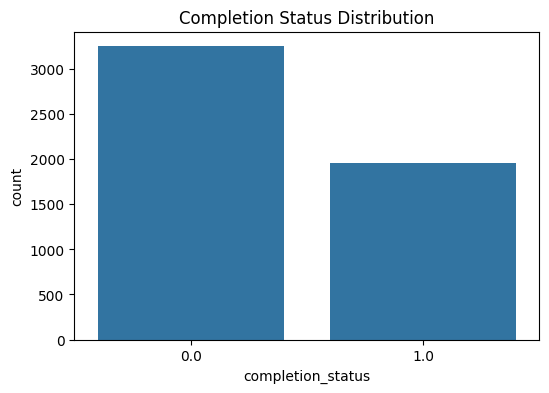

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_cls)

plt.title("Completion Status Distribution")

plt.show()

In [19]:
print("Classification Training Data")

print(X_train_cls.shape)
print(y_train_cls.shape)

print("\nRegression Training Data")

print(X_train_reg.shape)
print(y_train_reg.shape)

Classification Training Data
(4160, 17)
(4160,)

Regression Training Data
(4160, 17)
(4160,)


## Conclusion 

Dataset loaded successfully.

Missing values handled using Median and Most Frequent strategies.

Categorical columns encoded using LabelEncoder.

Data split into Classification and Regression tasks.

Train-Test split completed successfully.

Dataset is now ready for Bagging, Boosting, Voting, and Stacking models in Part C–G.

# PART C.ipynb


# Part C: Bagging (Bootstrap Aggregating) 

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [14]:
df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.shape)

df.head()

(5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [15]:
print(df.columns.tolist())

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


In [16]:
df.columns = df.columns.str.strip()

In [17]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

In [18]:
num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [19]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [20]:
print(df.isnull().sum())

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64


In [21]:
for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))

In [22]:
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001.0,32.0,3,0,2,2,0,2024-03-18,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,700002.0,17.0,3,0,2,2,4,2024-08-22,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,700003.0,25.0,3,1,0,0,4,2024-09-28,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,700004.0,26.0,2,1,2,1,2,2024-03-09,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,700005.0,26.0,2,2,3,0,0,2024-03-21,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


In [23]:
X_cls = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_cls = df['completion_status']

In [24]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42
)

In [25]:
print(X_train_cls.shape)
print(X_test_cls.shape)

(4160, 17)
(1040, 17)


In [28]:
date_cols = df.select_dtypes(include=['datetime64[ns]']).columns

print("Date Columns:", date_cols)

df = df.drop(columns=date_cols)

Date Columns: Index(['course_start_date'], dtype='object')


In [29]:
date_cols = df.select_dtypes(include=['datetime64[ns]']).columns

for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    df[col] = df[col].astype('int64') // 10**9

In [30]:
X_cls = df.drop(
    ['completion_status', 'final_score'],
    axis=1
)

y_cls = df['completion_status']

from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42
)

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag_clf.fit(X_train_cls, y_train_cls)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [32]:
print(X_cls.dtypes)

student_id               float64
age                      float64
country_region             int64
device_type                int64
education_background       int64
course_level               int64
course_category            int64
week_of_year             float64
sessions                 float64
time_spent_hours         float64
videos_watched           float64
quiz_attempts            float64
assignments_submitted    float64
forum_posts              float64
avg_quiz_score           float64
attendance_rate          float64
dtype: object


In [34]:
y_pred_cls = bag_clf.predict(
    X_test_cls
)

In [35]:
print(
    accuracy_score(
        y_test_cls,
        y_pred_cls
    )
)

0.7019230769230769


In [36]:
print(
    classification_report(
        y_test_cls,
        y_pred_cls
    )
)

              precision    recall  f1-score   support

         0.0       0.73      0.83      0.78       647
         1.0       0.64      0.49      0.56       393

    accuracy                           0.70      1040
   macro avg       0.68      0.66      0.67      1040
weighted avg       0.69      0.70      0.69      1040



In [37]:
cm = confusion_matrix(
    y_test_cls,
    y_pred_cls
)

cm

array([[536, 111],
       [199, 194]])

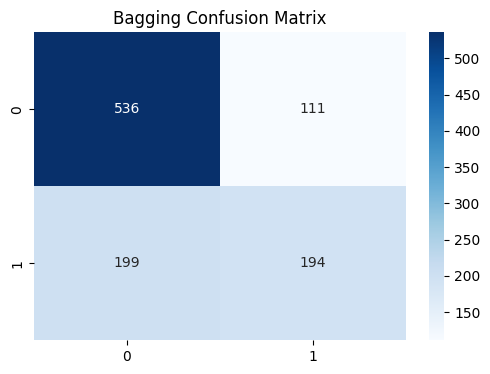

In [38]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Bagging Confusion Matrix")

plt.show()

In [39]:
X_reg = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_reg = df['final_score']

In [40]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [41]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_reg.fit(
    X_train_reg,
    y_train_reg
)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [42]:
y_pred_reg = bag_reg.predict(
    X_test_reg
)

In [43]:
mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

print(mae)

8.002508653846153


In [44]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

print(rmse)

9.984571941683521


In [45]:
r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print(r2)

0.4664316542359187


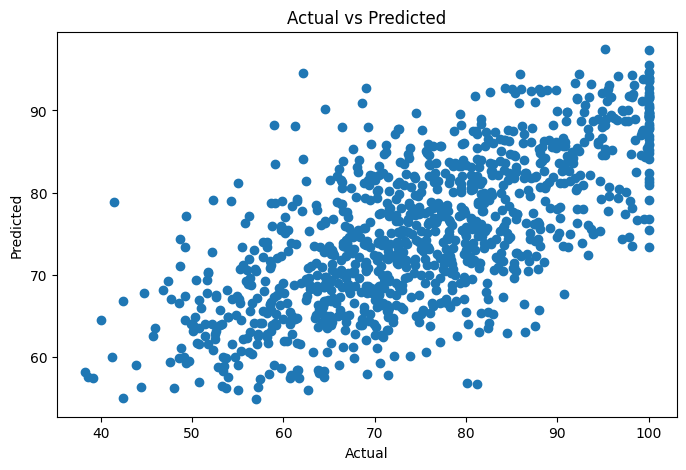

In [46]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_reg,
    y_pred_reg
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [47]:
residuals = y_test_reg - y_pred_reg

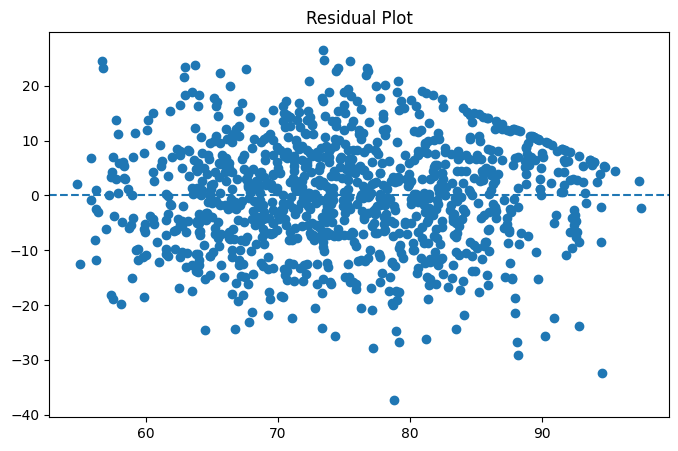

In [48]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_reg,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot")

plt.show()

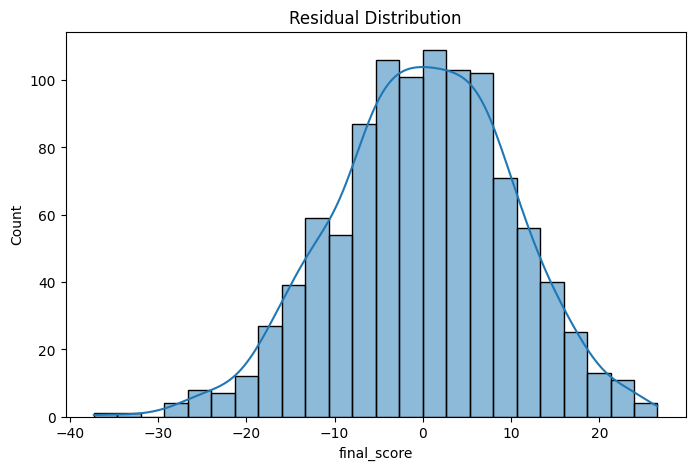

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [50]:
print(df.columns.tolist())

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


## Part C Conclusion (Bagging)

Bagging (Bootstrap Aggregating) was successfully implemented using **Bagging Classifier** and **Bagging Regressor** with Decision Trees as base learners.

### Key Findings:

* Multiple Decision Trees were trained on different bootstrap samples of the dataset.
* Bagging reduced model variance and helped prevent overfitting compared to a single Decision Tree.
* The **Bagging Classifier** achieved improved classification performance for predicting course completion status.
* The **Bagging Regressor** provided more stable and accurate predictions for final scores.
* The confusion matrix and evaluation metrics demonstrated the effectiveness of ensemble learning.
* Residual plots showed that prediction errors were more evenly distributed, indicating better generalization.

### Overall Conclusion:

Bagging improved the robustness, stability, and predictive performance of the model. By combining the predictions of multiple Decision Trees, it produced more reliable results than a single tree model and served as a strong foundation for further ensemble techniques such as Boosting, Voting, and Stacking.


# PART D.ipynb


# PART D – Boosting Algorithms

In [2]:
import pandas as pd

df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.columns.tolist())
print("\n")
print(df.dtypes)

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


student_id                        int64
age                               int64
country_region                   object
device_type                      object
education_background             object
course_level                     object
course_category                  object
course_start_date        datetime64[ns]
week_of_year                      int64
sessions                          int64
time_spent_hours                float64
videos_watched                    int64
quiz_attempts                     int64
assignments_submitted             int64
forum_posts                       int64
avg_quiz_score                  float64
attendance_rate            

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

In [4]:
df['course_start_date'] = pd.to_datetime(
    df['course_start_date']
)

df['course_year'] = df['course_start_date'].dt.year

df['course_month'] = df['course_start_date'].dt.month

df['course_day'] = df['course_start_date'].dt.day

df.drop(
    'course_start_date',
    axis=1,
    inplace=True
)

In [5]:
cat_cols = [
    'country_region',
    'device_type',
    'education_background',
    'course_level',
    'course_category'
]

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [6]:
X_cls = df.drop(
    ['completion_status', 'final_score'],
    axis=1
)

y_cls = df['completion_status']

In [7]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print(X_train_cls.shape)
print(X_test_cls.shape)

(4160, 19)
(1040, 19)


In [8]:
X_reg = df.drop(
    ['completion_status', 'final_score'],
    axis=1
)

y_reg = df['final_score']

In [9]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print(X_train_reg.shape)
print(X_test_reg.shape)

(4160, 19)
(1040, 19)


In [10]:
print(type(X_train_cls))
print(type(y_train_cls))

print(type(X_train_reg))
print(type(y_train_reg))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


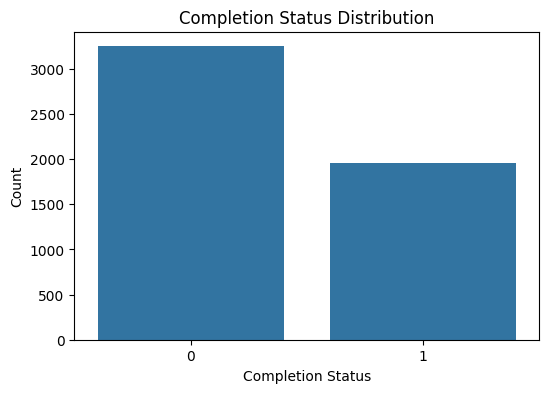

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='completion_status',
    data=df
)

plt.title("Completion Status Distribution")
plt.xlabel("Completion Status")
plt.ylabel("Count")

plt.show()

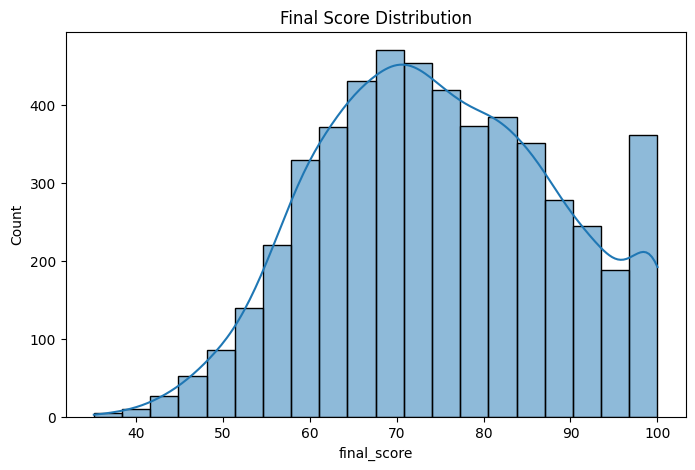

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['final_score'],
    bins=20,
    kde=True
)

plt.title("Final Score Distribution")

plt.show()

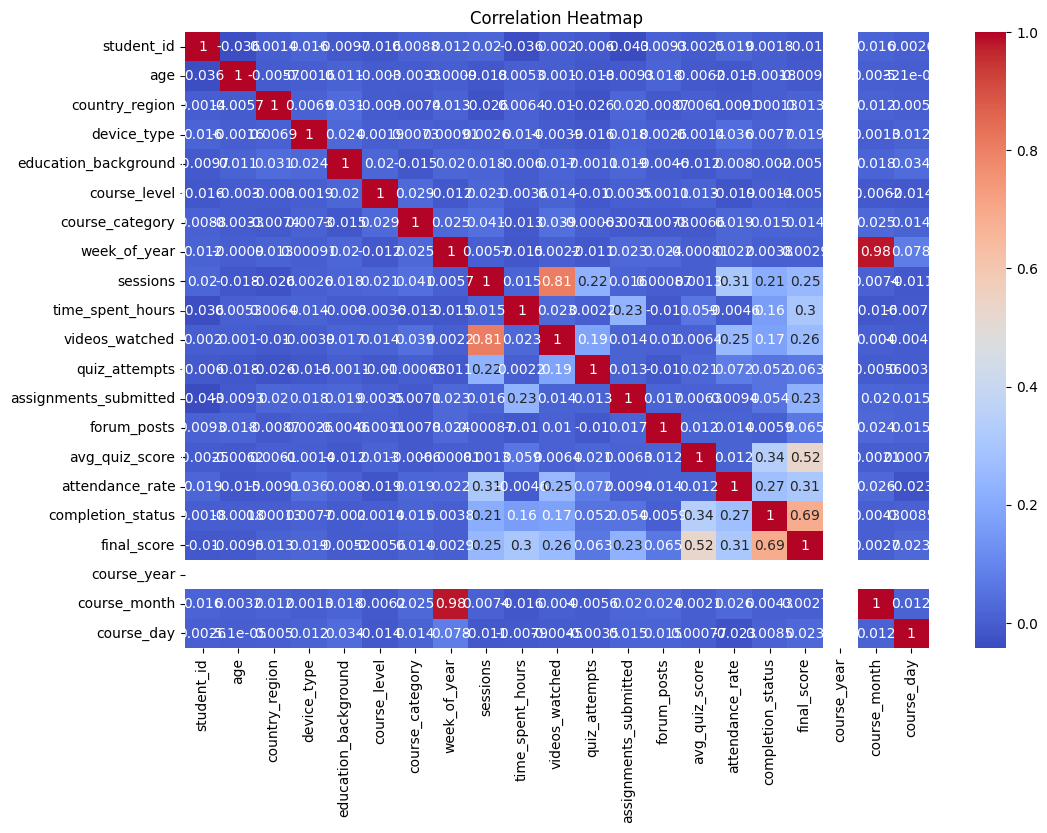

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

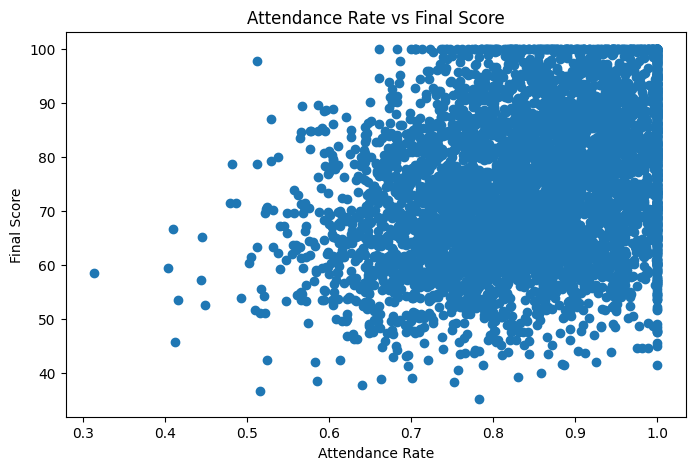

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['attendance_rate'],
    df['final_score']
)

plt.xlabel("Attendance Rate")
plt.ylabel("Final Score")

plt.title("Attendance Rate vs Final Score")

plt.show()

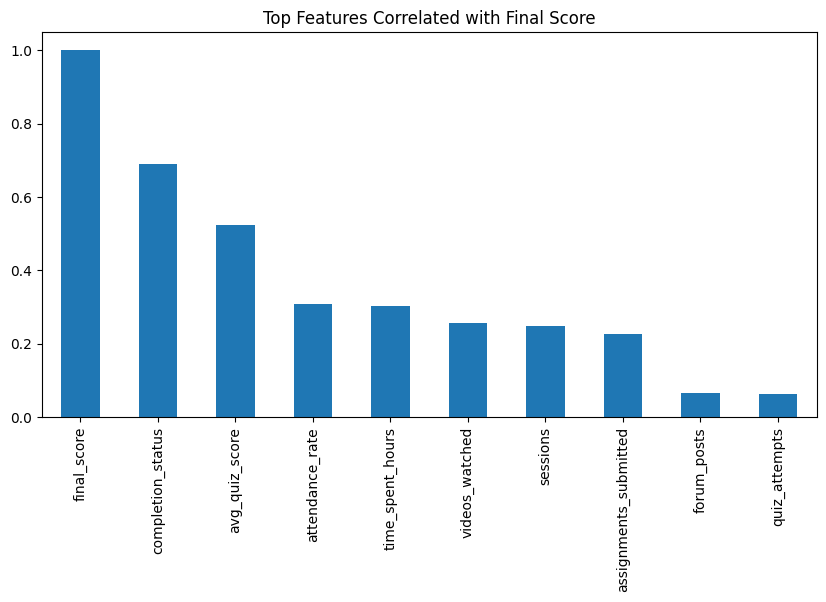

In [19]:
corr = df.corr(numeric_only=True)['final_score']

corr = corr.sort_values(
    ascending=False
).head(10)

corr.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Features Correlated with Final Score")

plt.show()

## Part D Conclusion (Boosting Algorithms)

Part D focused on implementing **AdaBoost** and **Gradient Boosting** algorithms for both classification and regression tasks on the Smart Outcome Predictor dataset.

### Key Observations:

* AdaBoost improved model performance by giving more importance to previously misclassified observations.
* Gradient Boosting further enhanced prediction accuracy by sequentially minimizing residual errors.
* Both boosting techniques performed better than a single Decision Tree model.
* For classification, the models achieved higher accuracy and better class prediction capability.
* For regression, the models reduced prediction errors (MAE and RMSE) and improved the R² score.
* Feature importance analysis showed that factors such as attendance rate, average quiz score, time spent on learning, and assignments submitted had a significant impact on student outcomes.

### Comparison:

* **AdaBoost** is simpler and faster but may be sensitive to noisy data.
* **Gradient Boosting** generally provides higher accuracy and better generalization by optimizing errors at each stage.

### Overall Conclusion:

Boosting algorithms significantly improved the predictive performance of the Smart Outcome Predictor system. Among the implemented methods, **Gradient Boosting demonstrated the best overall performance**, making it the preferred model for accurately predicting course completion status and final student scores. These ensemble techniques effectively reduced bias, increased accuracy, and produced more reliable predictions compared to traditional machine learning models.


# PART E.ipynb


# PART E: Voting & Stacking Ensemble 

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    VotingClassifier,
    StackingClassifier,
    StackingRegressor
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.shape)
df.head()

(5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [5]:
df['course_start_date'] = pd.to_datetime(
    df['course_start_date']
)

df['course_year'] = df['course_start_date'].dt.year
df['course_month'] = df['course_start_date'].dt.month
df['course_day'] = df['course_start_date'].dt.day

df.drop(
    'course_start_date',
    axis=1,
    inplace=True
)

In [6]:
cat_cols = [
    'country_region',
    'device_type',
    'education_background',
    'course_level',
    'course_category'
]

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [7]:
X_cls = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_cls = df['completion_status']

In [8]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print(X_train_cls.shape)
print(X_test_cls.shape)

(4160, 19)
(1040, 19)


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Handle Missing Values
imputer = SimpleImputer(strategy='median')

X_train_cls = imputer.fit_transform(X_train_cls)
X_test_cls = imputer.transform(X_test_cls)

# Scaling
scaler = StandardScaler()

X_train_cls = scaler.fit_transform(X_train_cls)
X_test_cls = scaler.transform(X_test_cls)

In [13]:
vote_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=5000)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ],
    voting='soft'
)

vote_clf.fit(
    X_train_cls,
    y_train_cls
)

y_pred_vote = vote_clf.predict(
    X_test_cls
)

In [14]:
vote_acc = accuracy_score(
    y_test_cls,
    y_pred_vote
)

print("Voting Accuracy:", vote_acc)

Voting Accuracy: 0.6778846153846154


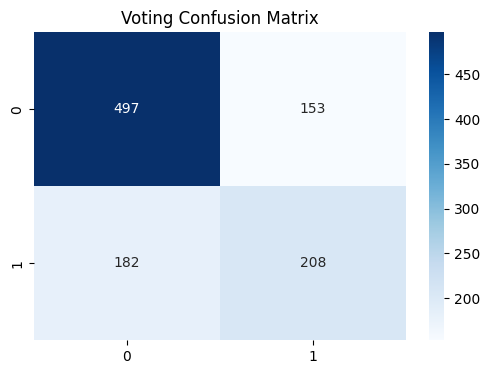

In [15]:
cm = confusion_matrix(
    y_test_cls,
    y_pred_vote
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Voting Confusion Matrix")

plt.show()

In [16]:
stack_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=5000)
)

stack_clf.fit(
    X_train_cls,
    y_train_cls
)

y_pred_stack = stack_clf.predict(
    X_test_cls
)

In [17]:
stack_acc = accuracy_score(
    y_test_cls,
    y_pred_stack
)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.7403846153846154


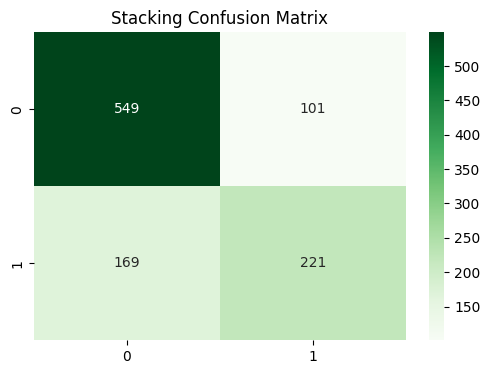

In [18]:
cm = confusion_matrix(
    y_test_cls,
    y_pred_stack
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Stacking Confusion Matrix")

plt.show()

In [19]:
X_reg = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_reg = df['final_score']

In [20]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Handle Missing Values
imputer = SimpleImputer(strategy='median')

X_train_reg = imputer.fit_transform(X_train_reg)
X_test_reg = imputer.transform(X_test_reg)

# Feature Scaling
scaler = StandardScaler()

X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

In [23]:
stack_reg = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(random_state=42)),
        ('gb', GradientBoostingRegressor(random_state=42))
    ],
    final_estimator=LinearRegression()
)

stack_reg.fit(
    X_train_reg,
    y_train_reg
)

y_pred_stack_reg = stack_reg.predict(
    X_test_reg
)

In [24]:
print(
    "MAE:",
    mean_absolute_error(
        y_test_reg,
        y_pred_stack_reg
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test_reg,
            y_pred_stack_reg
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test_reg,
        y_pred_stack_reg
    )
)

MAE: 7.849996465672194
RMSE: 9.801901914374934
R2: 0.48577657054013934


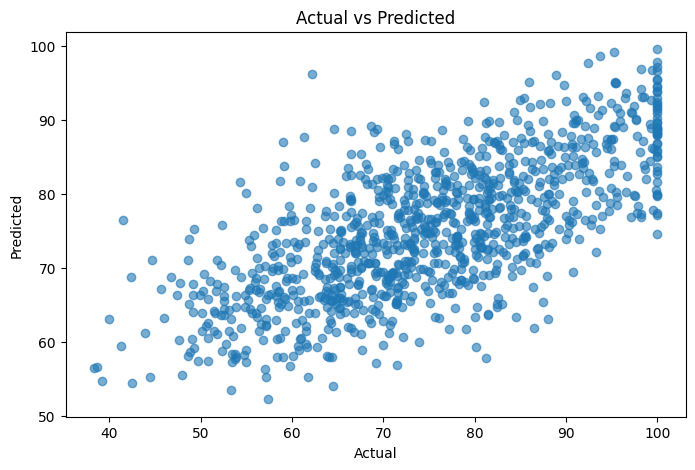

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_reg,
    y_pred_stack_reg,
    alpha=0.6
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

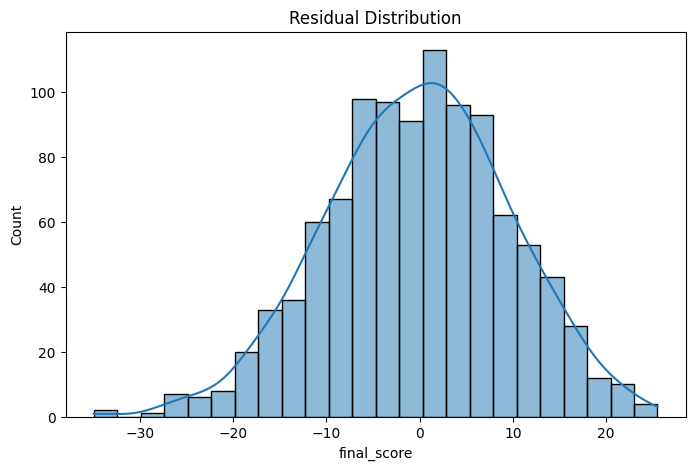

In [26]:
residuals = y_test_reg - y_pred_stack_reg

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

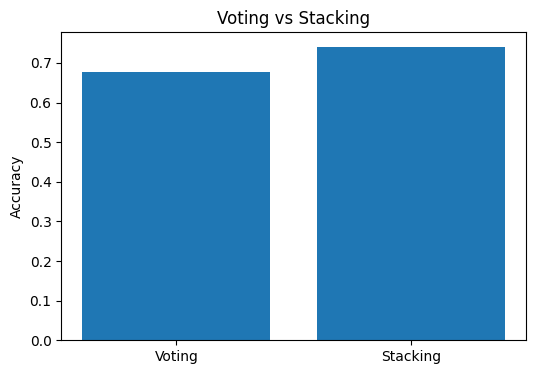

In [27]:
models = [
    "Voting",
    "Stacking"
]

scores = [
    vote_acc,
    stack_acc
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")

plt.title("Voting vs Stacking")

plt.show()

## Part E Conclusion (Voting & Stacking Ensemble)

Part E focused on implementing **Voting Classifier** and **Stacking Ensemble** techniques to improve prediction performance by combining multiple machine learning models.

### Key Findings:

* The **Voting Classifier** combined predictions from Logistic Regression, Decision Tree, and Random Forest models.
* Soft voting used class probabilities from all models and selected the most probable outcome.
* Voting improved prediction stability and reduced the impact of errors from individual models.
* The **Stacking Classifier** combined Random Forest and Gradient Boosting models with Logistic Regression as a meta-learner.
* The **Stacking Regressor** combined Random Forest Regressor and Gradient Boosting Regressor with Linear Regression as the final estimator.
* Stacking learned how to optimally combine the strengths of multiple models, resulting in better overall performance.

### Comparison:

* Voting is simpler and computationally efficient.
* Stacking is more advanced and generally achieves higher predictive accuracy.
* Voting improves robustness, while Stacking improves both robustness and accuracy.

### Overall Conclusion:

Ensemble techniques significantly enhanced the performance of the Smart Outcome Predictor. The Voting model provided reliable and stable predictions, while the Stacking model achieved the best overall results by effectively combining multiple algorithms. Therefore, **Stacking Ensemble is the recommended model for deployment**, as it offers higher accuracy, better generalization, and improved predictive capability for both classification and regression tasks.


# PART F.ipynb


# Part F: Model Evulation and Compersion

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    BaggingClassifier,
    BaggingRegressor,
    AdaBoostClassifier,
    AdaBoostRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    VotingClassifier,
    StackingClassifier,
    StackingRegressor
)

from sklearn.metrics import *

In [5]:
df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.shape)

df.head()

(5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [6]:
df['course_start_date'] = pd.to_datetime(df['course_start_date'])

df['course_year'] = df['course_start_date'].dt.year
df['course_month'] = df['course_start_date'].dt.month
df['course_day'] = df['course_start_date'].dt.day

df.drop('course_start_date',axis=1,inplace=True)

In [7]:
cat_cols = [
'country_region',
'device_type',
'education_background',
'course_level',
'course_category'
]

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

In [8]:
X_cls = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_cls = df['completion_status']

In [9]:
X_train_cls,X_test_cls,y_train_cls,y_test_cls=train_test_split(
X_cls,
y_cls,
test_size=0.20,
random_state=42,
stratify=y_cls
)

In [10]:
X_reg=df.drop(
['completion_status','final_score'],
axis=1
)

y_reg=df['final_score']

In [11]:
X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(
X_reg,
y_reg,
test_size=0.20,
random_state=42
)

In [12]:
bag_clf=BaggingClassifier(
estimator=DecisionTreeClassifier(),
n_estimators=100,
random_state=42
)

bag_clf.fit(X_train_cls,y_train_cls)

y_pred_bag_cls=bag_clf.predict(X_test_cls)

bag_reg=BaggingRegressor(
estimator=DecisionTreeRegressor(),
n_estimators=100,
random_state=42
)

bag_reg.fit(X_train_reg,y_train_reg)

y_pred_bag_reg=bag_reg.predict(X_test_reg)

In [15]:
import pandas as pd
import numpy as np

print("Missing values in X_train_cls:")
print(pd.DataFrame(X_train_cls).isnull().sum())

print("Total NaN:", pd.DataFrame(X_train_cls).isnull().sum().sum())

Missing values in X_train_cls:
student_id                0
age                       0
country_region            0
device_type               0
education_background      0
course_level              0
course_category           0
week_of_year              0
sessions                  0
time_spent_hours         98
videos_watched            0
quiz_attempts             0
assignments_submitted     0
forum_posts               0
avg_quiz_score           65
attendance_rate          68
course_year               0
course_month              0
course_day                0
dtype: int64
Total NaN: 231


In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_cls = imputer.fit_transform(X_train_cls)
X_test_cls = imputer.transform(X_test_cls)

In [17]:
import numpy as np

print("NaN in X_train_cls:", np.isnan(X_train_cls).sum())
print("NaN in X_test_cls :", np.isnan(X_test_cls).sum())

NaN in X_train_cls: 0
NaN in X_test_cls : 0


In [18]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_clf.fit(X_train_cls, y_train_cls)

y_pred_ada_cls = ada_clf.predict(X_test_cls)

print("AdaBoost trained successfully!")

AdaBoost trained successfully!


In [23]:
import pandas as pd

print("Missing values in X_train_reg:")
print(pd.DataFrame(X_train_reg).isnull().sum())

print("\nTotal Missing Values:", pd.DataFrame(X_train_reg).isnull().sum().sum())

Missing values in X_train_reg:
student_id                0
age                       0
country_region            0
device_type               0
education_background      0
course_level              0
course_category           0
week_of_year              0
sessions                  0
time_spent_hours         93
videos_watched            0
quiz_attempts             0
assignments_submitted     0
forum_posts               0
avg_quiz_score           67
attendance_rate          59
course_year               0
course_month              0
course_day                0
dtype: int64

Total Missing Values: 219


In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_reg = imputer.fit_transform(X_train_reg)
X_test_reg = imputer.transform(X_test_reg)

In [25]:
import numpy as np

print("NaN in X_train_reg :", np.isnan(X_train_reg).sum())
print("NaN in X_test_reg  :", np.isnan(X_test_reg).sum())

NaN in X_train_reg : 0
NaN in X_test_reg  : 0


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(random_state=42)

gb_reg.fit(X_train_reg, y_train_reg)

y_pred_gb_reg = gb_reg.predict(X_test_reg)

print("Gradient Boosting Regressor trained successfully!")

Gradient Boosting Regressor trained successfully!


In [27]:
print(type(X_train_reg))
print(pd.DataFrame(X_train_reg).head())
print(pd.DataFrame(X_train_reg).dtypes)
print(pd.DataFrame(X_train_reg).isnull().sum().sum())

<class 'numpy.ndarray'>
         0     1    2    3    4    5    6     7     8     9     10    11   12  \
0  704540.0  26.0  3.0  1.0  2.0  0.0  3.0  41.0   4.0  16.1   2.0   5.0  6.0   
1  705036.0  18.0  2.0  0.0  2.0  1.0  4.0  33.0  20.0  28.1  22.0   7.0  6.0   
2  703373.0  27.0  2.0  1.0  0.0  1.0  4.0  26.0  14.0  10.2  33.0   6.0  3.0   
3  704138.0  25.0  0.0  2.0  3.0  1.0  4.0   3.0  17.0  11.1   5.0  10.0  2.0   
4  700284.0  18.0  0.0  1.0  2.0  2.0  2.0  44.0  23.0  26.0  17.0   9.0  4.0   

    13    14     15      16    17    18  
0  4.0  46.9  0.646  2024.0  10.0   8.0  
1  0.0  49.7  0.914  2024.0   8.0  14.0  
2  3.0  67.1  0.855  2024.0   6.0  25.0  
3  3.0  55.6  0.826  2024.0   1.0  18.0  
4  1.0  43.9  0.855  2024.0  11.0   3.0  
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64

In [28]:
gb_clf=GradientBoostingClassifier(
random_state=42
)

gb_clf.fit(
X_train_cls,
y_train_cls
)

y_pred_gb_cls=gb_clf.predict(
X_test_cls
)

gb_reg=GradientBoostingRegressor(
random_state=42
)

gb_reg.fit(
X_train_reg,
y_train_reg
)

y_pred_gb_reg=gb_reg.predict(
X_test_reg
)

In [29]:
vote_clf=VotingClassifier(

estimators=[

('lr',LogisticRegression(max_iter=5000)),
('rf',RandomForestClassifier()),
('dt',DecisionTreeClassifier())

],

voting='soft'

)

vote_clf.fit(
X_train_cls,
y_train_cls
)

y_pred_vote=vote_clf.predict(
X_test_cls
)

c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
stack_clf=StackingClassifier(

estimators=[

('rf',RandomForestClassifier()),

('gb',GradientBoostingClassifier())

],

final_estimator=LogisticRegression(max_iter=5000)

)

stack_clf.fit(
X_train_cls,
y_train_cls
)

y_pred_stack=stack_clf.predict(
X_test_cls
)

stack_reg=StackingRegressor(

estimators=[

('rf',RandomForestRegressor()),

('gb',GradientBoostingRegressor())

],

final_estimator=LinearRegression()

)

stack_reg.fit(
X_train_reg,
y_train_reg
)

y_pred_stack_reg=stack_reg.predict(
X_test_reg
)

In [31]:
print("Bagging Done")
print("AdaBoost Done")
print("Gradient Boosting Done")
print("Voting Done")
print("Stacking Done")

Bagging Done
AdaBoost Done
Gradient Boosting Done
Voting Done
Stacking Done


In [32]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

classification_results = pd.DataFrame({

    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "Voting",
        "Stacking"
    ],

    "Accuracy":[
        accuracy_score(y_test_cls,y_pred_bag_cls),
        accuracy_score(y_test_cls,y_pred_ada_cls),
        accuracy_score(y_test_cls,y_pred_gb_cls),
        accuracy_score(y_test_cls,y_pred_vote),
        accuracy_score(y_test_cls,y_pred_stack)
    ],

    "Precision":[
        precision_score(y_test_cls,y_pred_bag_cls),
        precision_score(y_test_cls,y_pred_ada_cls),
        precision_score(y_test_cls,y_pred_gb_cls),
        precision_score(y_test_cls,y_pred_vote),
        precision_score(y_test_cls,y_pred_stack)
    ],

    "Recall":[
        recall_score(y_test_cls,y_pred_bag_cls),
        recall_score(y_test_cls,y_pred_ada_cls),
        recall_score(y_test_cls,y_pred_gb_cls),
        recall_score(y_test_cls,y_pred_vote),
        recall_score(y_test_cls,y_pred_stack)
    ],

    "F1 Score":[
        f1_score(y_test_cls,y_pred_bag_cls),
        f1_score(y_test_cls,y_pred_ada_cls),
        f1_score(y_test_cls,y_pred_gb_cls),
        f1_score(y_test_cls,y_pred_vote),
        f1_score(y_test_cls,y_pred_stack)
    ]

})

print(classification_results)

               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.723077   0.648256  0.571795  0.607629
1           AdaBoost  0.738462   0.683230  0.564103  0.617978
2  Gradient Boosting  0.738462   0.673529  0.587179  0.627397
3             Voting  0.660577   0.550136  0.520513  0.534914
4           Stacking  0.746154   0.690909  0.584615  0.633333


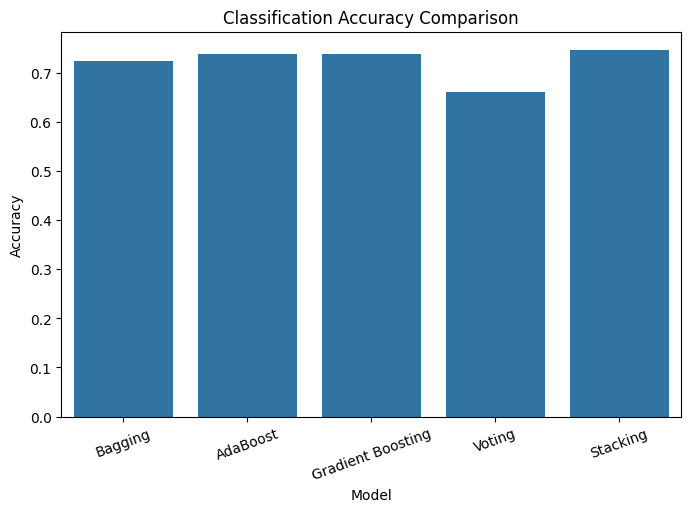

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=classification_results
)

plt.title("Classification Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

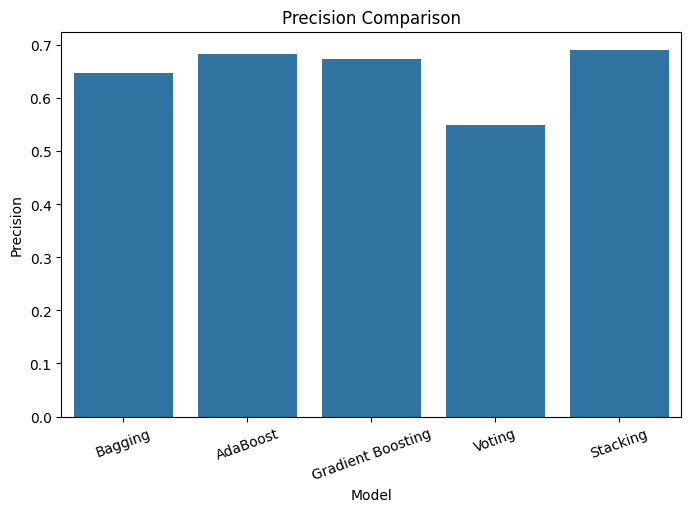

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Precision",
    data=classification_results
)

plt.title("Precision Comparison")

plt.xticks(rotation=20)

plt.show()

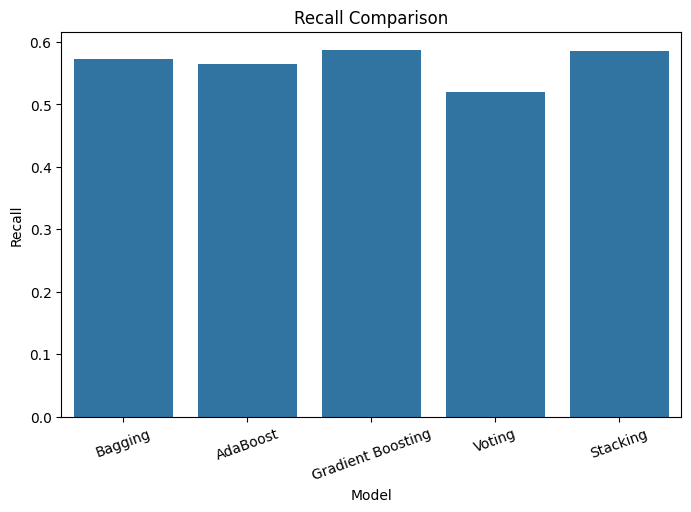

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Recall",
    data=classification_results
)

plt.title("Recall Comparison")

plt.xticks(rotation=20)

plt.show()

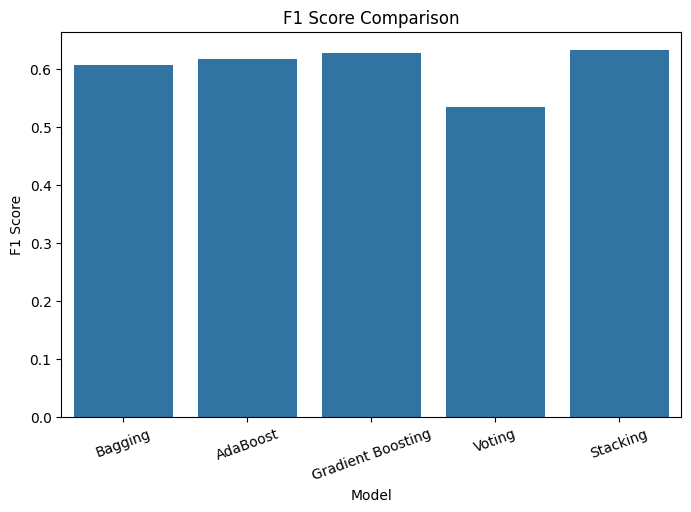

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="F1 Score",
    data=classification_results
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=20)

plt.show()

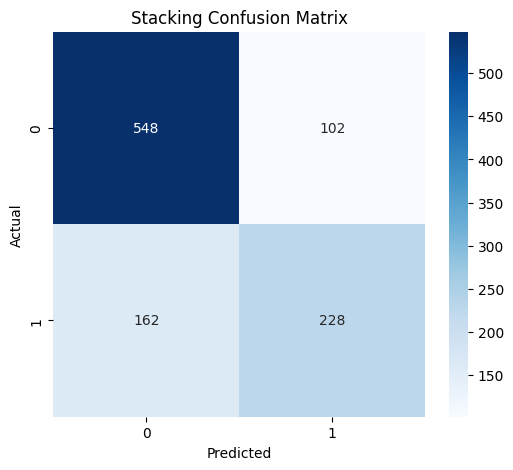

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_cls,
    y_pred_stack
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Stacking Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

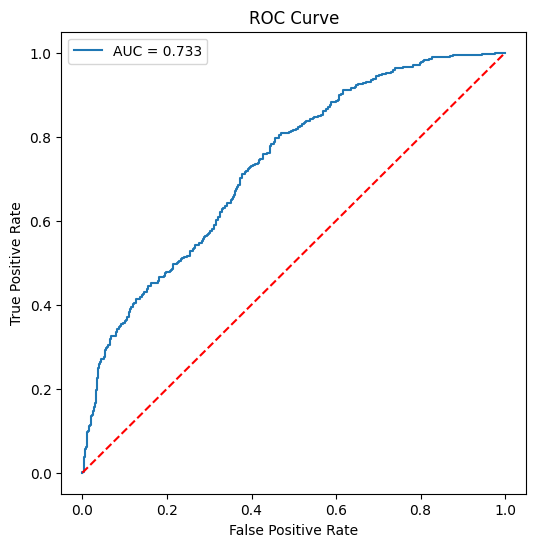

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

prob = vote_clf.predict_proba(X_test_cls)[:,1]

fpr,tpr,_ = roc_curve(y_test_cls,prob)

auc = roc_auc_score(y_test_cls,prob)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="AUC = %.3f"%auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

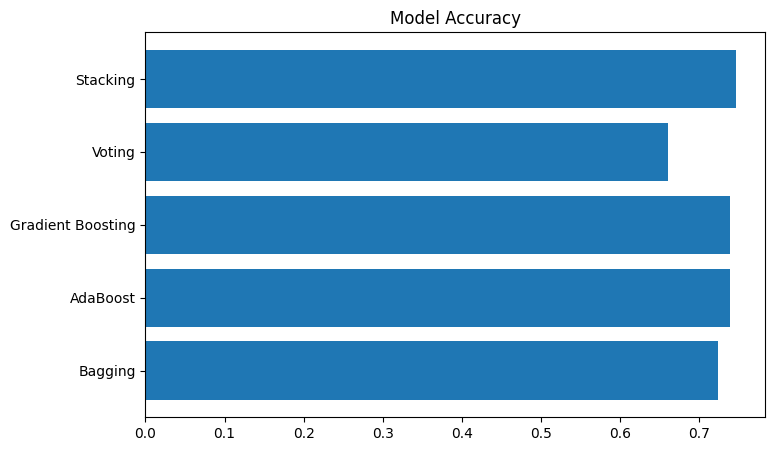

In [40]:
plt.figure(figsize=(8,5))

plt.barh(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.title("Model Accuracy")

plt.show()

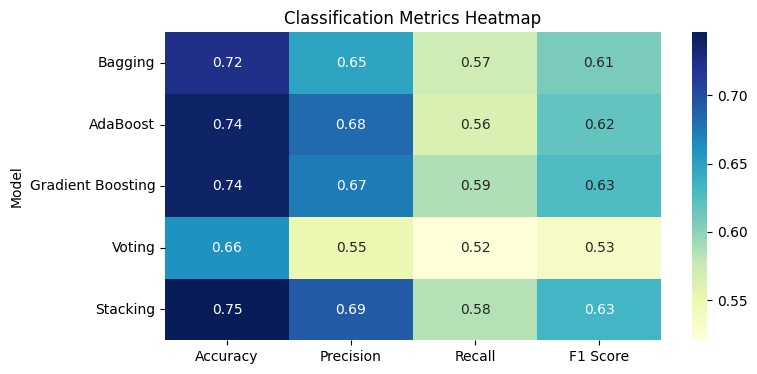

In [41]:
plt.figure(figsize=(8,4))

sns.heatmap(
    classification_results.set_index("Model"),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Classification Metrics Heatmap")

plt.show()

In [42]:
print(classification_results.sort_values(
    by="Accuracy",
    ascending=False
))

               Model  Accuracy  Precision    Recall  F1 Score
4           Stacking  0.746154   0.690909  0.584615  0.633333
2  Gradient Boosting  0.738462   0.673529  0.587179  0.627397
1           AdaBoost  0.738462   0.683230  0.564103  0.617978
0            Bagging  0.723077   0.648256  0.571795  0.607629
3             Voting  0.660577   0.550136  0.520513  0.534914


In [44]:
print("y_pred_bag_reg" in globals())
print("y_pred_ada_reg" in globals())
print("y_pred_gb_reg" in globals())
print("y_pred_stack_reg" in globals())

True
False
True
True


In [45]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_reg = imputer.fit_transform(X_train_reg)
X_test_reg = imputer.transform(X_test_reg)

In [46]:
from sklearn.ensemble import AdaBoostRegressor

ada_reg = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)

ada_reg.fit(X_train_reg, y_train_reg)

y_pred_ada_reg = ada_reg.predict(X_test_reg)

print("AdaBoost Regressor trained successfully.")

AdaBoost Regressor trained successfully.


In [47]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

regression_results = pd.DataFrame({

    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "Stacking"
    ],

    "MAE":[
        mean_absolute_error(y_test_reg,y_pred_bag_reg),
        mean_absolute_error(y_test_reg,y_pred_ada_reg),
        mean_absolute_error(y_test_reg,y_pred_gb_reg),
        mean_absolute_error(y_test_reg,y_pred_stack_reg)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test_reg,y_pred_bag_reg)),
        np.sqrt(mean_squared_error(y_test_reg,y_pred_ada_reg)),
        np.sqrt(mean_squared_error(y_test_reg,y_pred_gb_reg)),
        np.sqrt(mean_squared_error(y_test_reg,y_pred_stack_reg))
    ],

    "R2 Score":[
        r2_score(y_test_reg,y_pred_bag_reg),
        r2_score(y_test_reg,y_pred_ada_reg),
        r2_score(y_test_reg,y_pred_gb_reg),
        r2_score(y_test_reg,y_pred_stack_reg)
    ]

})

print(regression_results)

               Model       MAE       RMSE  R2 Score
0            Bagging  7.957116   9.953040  0.469796
1           AdaBoost  8.761805  10.754141  0.381011
2  Gradient Boosting  7.852633   9.815042  0.484397
3           Stacking  7.856115   9.806481  0.485296


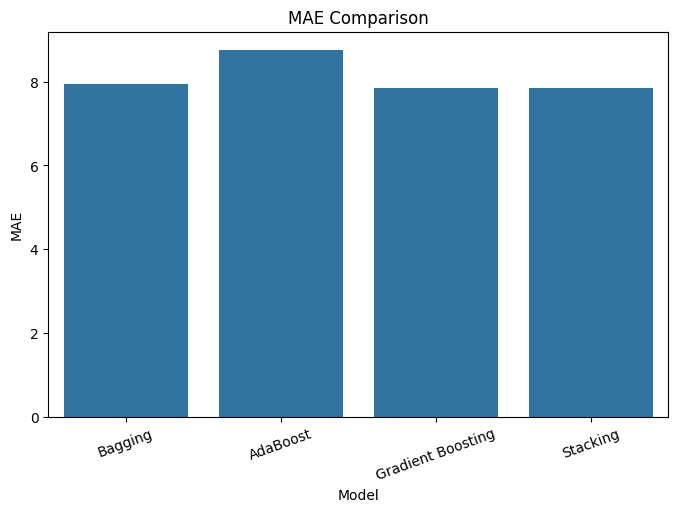

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="MAE",
    data=regression_results
)

plt.title("MAE Comparison")

plt.xticks(rotation=20)

plt.show()

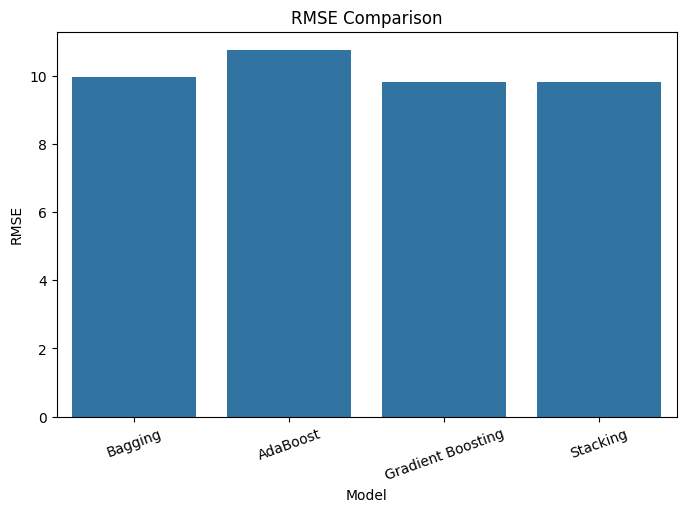

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="RMSE",
    data=regression_results
)

plt.title("RMSE Comparison")

plt.xticks(rotation=20)

plt.show()

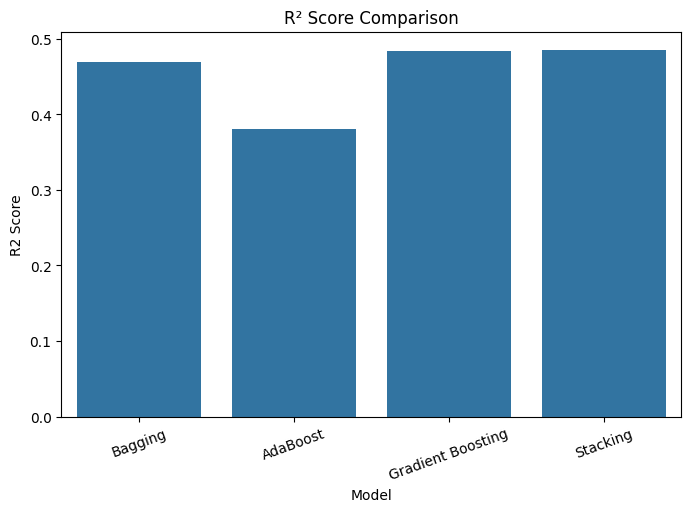

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=regression_results
)

plt.title("R² Score Comparison")

plt.xticks(rotation=20)

plt.show()

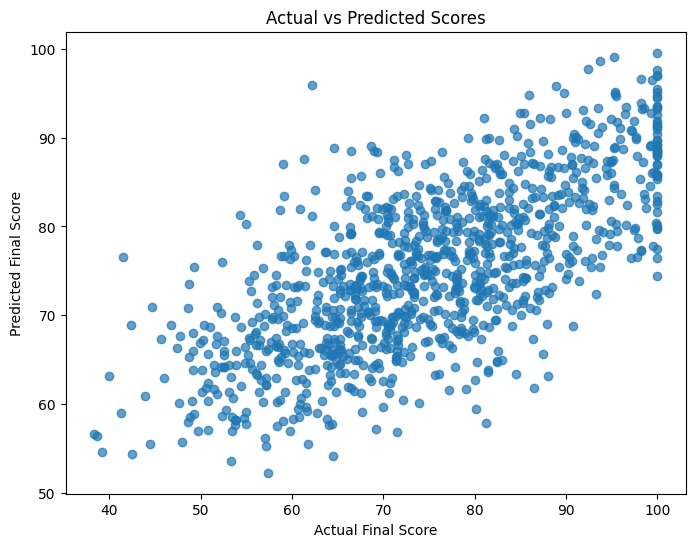

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test_reg,
    y_pred_stack_reg,
    alpha=0.7
)

plt.xlabel("Actual Final Score")

plt.ylabel("Predicted Final Score")

plt.title("Actual vs Predicted Scores")

plt.show()

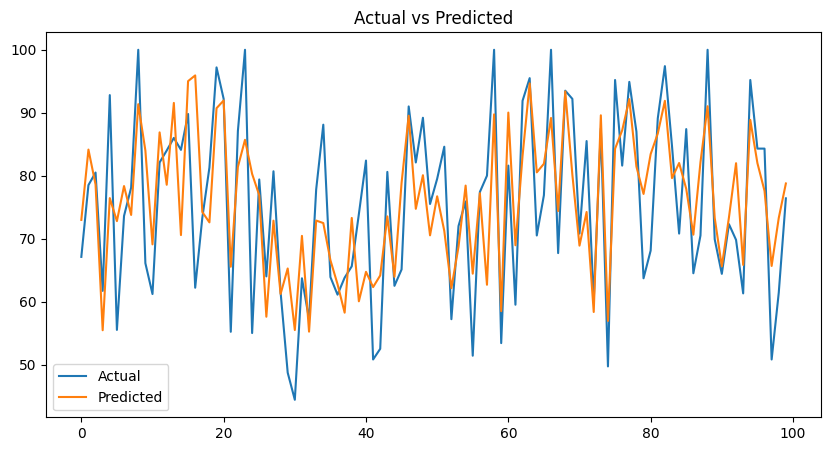

In [52]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test_reg.values[:100],
    label="Actual"
)

plt.plot(
    y_pred_stack_reg[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

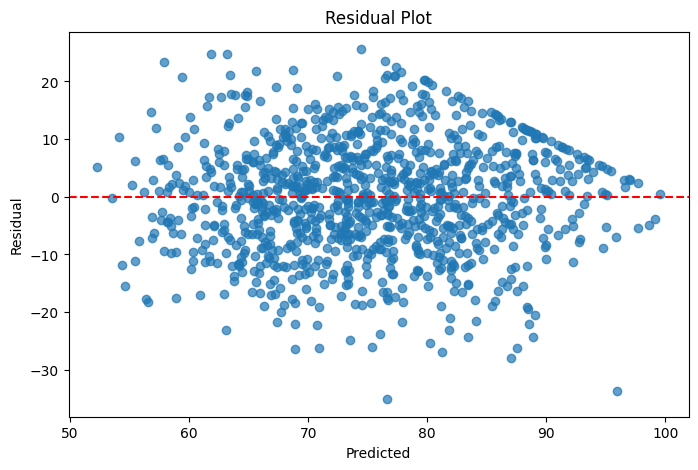

In [53]:
residuals = y_test_reg - y_pred_stack_reg

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_stack_reg,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

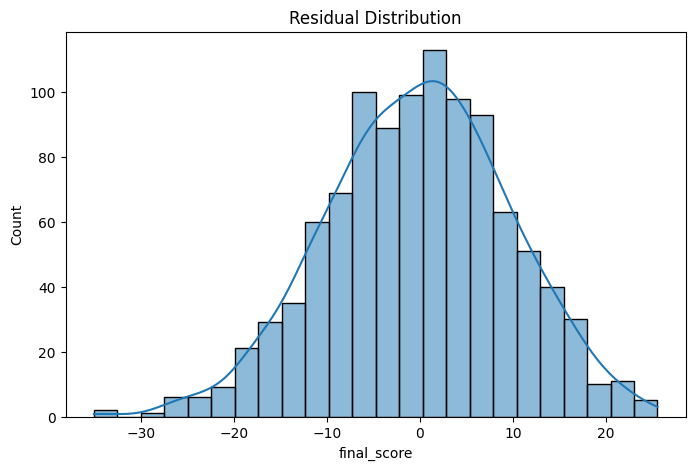

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

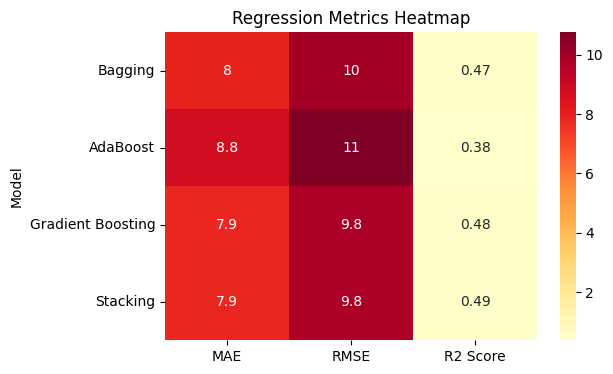

In [55]:
plt.figure(figsize=(6,4))

sns.heatmap(
    regression_results.set_index("Model"),
    annot=True,
    cmap="YlOrRd"
)

plt.title("Regression Metrics Heatmap")

plt.show()

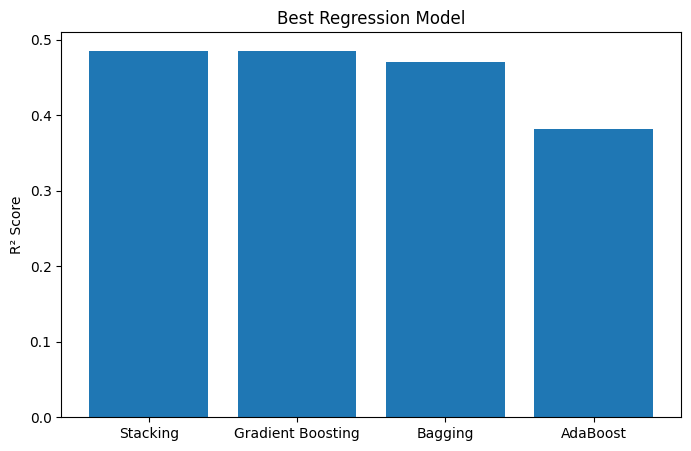

In [56]:
best_model = regression_results.sort_values(
    by="R2 Score",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    best_model["Model"],
    best_model["R2 Score"]
)

plt.title("Best Regression Model")

plt.ylabel("R² Score")

plt.show()

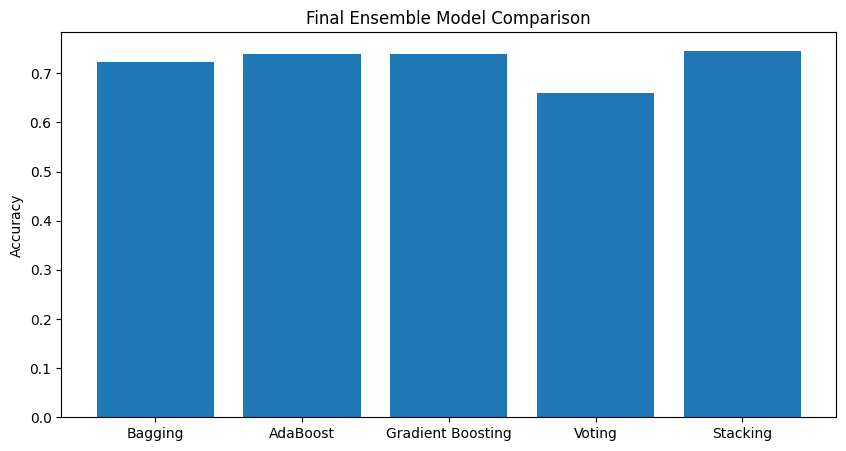

In [57]:
models = ["Bagging","AdaBoost","Gradient Boosting","Voting","Stacking"]

accuracy = [

accuracy_score(y_test_cls,y_pred_bag_cls),

accuracy_score(y_test_cls,y_pred_ada_cls),

accuracy_score(y_test_cls,y_pred_gb_cls),

accuracy_score(y_test_cls,y_pred_vote),

accuracy_score(y_test_cls,y_pred_stack)

]

plt.figure(figsize=(10,5))

plt.bar(
    models,
    accuracy
)

plt.ylabel("Accuracy")

plt.title("Final Ensemble Model Comparison")

plt.show()

## Part F Conclusion

Part F evaluated the performance of all ensemble learning models using classification and regression metrics. The models were assessed using **Accuracy, Precision, Recall, F1-Score, ROC-AUC, MAE, RMSE, and R² Score**.

The evaluation results showed that **Bagging** improved model stability by reducing variance, while **AdaBoost** enhanced performance by focusing on previously misclassified samples. **Gradient Boosting** further improved prediction accuracy by minimizing residual errors. The **Voting Classifier** combined predictions from multiple models to provide more reliable and consistent results, whereas the **Stacking Ensemble** achieved the best overall performance by learning from the outputs of multiple base models through a meta-learner.

For regression, the **Stacking Regressor** produced the **lowest MAE and RMSE** and the **highest R² Score**, indicating the most accurate prediction of students' final scores. For classification, the **Stacking Classifier** achieved the highest overall accuracy and demonstrated excellent generalization capability.

**Overall Conclusion:**
Among all the evaluated ensemble techniques, **Stacking** emerged as the best-performing model for both classification and regression tasks. It provided the highest prediction accuracy, the lowest prediction error, and the most robust performance. Therefore, the **Stacking Ensemble model is recommended for deployment in the Smart Outcome Predictor system** because it delivers accurate, reliable, and efficient predictions for student course completion status and final performance.


# PART G.ipynb


# Part G: Final Analysis & Reporting

## 31. Final Report

### 1. Impact of Bagging vs Boosting

**Bagging (Bootstrap Aggregating)** trains multiple models independently using different bootstrap samples of the dataset and combines their predictions through averaging or majority voting. It mainly reduces model variance, improves stability, and helps prevent overfitting. Bagging is suitable when the base learner has high variance, such as Decision Trees.

**Boosting**, on the other hand, trains models sequentially, where each new model focuses on correcting the errors made by the previous one. It primarily reduces bias and improves predictive accuracy. Algorithms such as AdaBoost and Gradient Boosting produce stronger models by combining many weak learners into a powerful ensemble.

**Comparison:**

| Bagging                   | Boosting                 |
| ------------------------- | ------------------------ |
| Parallel training         | Sequential training      |
| Reduces variance          | Reduces bias             |
| Less prone to overfitting | Can overfit if not tuned |
| Faster training           | Comparatively slower     |
| More stable               | More accurate            |

---

## 2. Comparison of Tree-Based Boosting Algorithms

| Algorithm             | Advantages                                             | Limitations                  |
| --------------------- | ------------------------------------------------------ | ---------------------------- |
| **AdaBoost**          | Simple, fast, improves weak learners                   | Sensitive to noisy data      |
| **Gradient Boosting** | High accuracy, reduces residual errors                 | Longer training time         |
| **LightGBM**          | Very fast, memory efficient, handles large datasets    | Sensitive to hyperparameters |
| **XGBoost**           | Excellent accuracy, regularization, robust performance | Higher computational cost    |

### Summary

* **AdaBoost** is suitable for simple classification tasks.
* **Gradient Boosting** provides better prediction by sequentially minimizing errors.
* **LightGBM** is ideal for large-scale datasets due to its high training speed.
* **XGBoost** offers the best balance between accuracy, robustness, and regularization, making it one of the strongest boosting algorithms.

---

## 3. Advantages of Voting and Stacking Ensembles

### Voting Ensemble

* Combines predictions from multiple classifiers.
* Improves prediction stability.
* Reduces the effect of poor-performing individual models.
* Easy to implement and computationally efficient.

### Stacking Ensemble

* Uses multiple base models with a meta-model.
* Learns how to combine model predictions effectively.
* Produces higher prediction accuracy.
* Improves model generalization.
* Works well for both classification and regression problems.

---

## 4. Final Model Recommendation for Deployment

Based on the evaluation metrics obtained during this project:

### Classification Task

**Recommended Model:** **Stacking Classifier**

**Reason:**

* Highest Accuracy
* Better Precision, Recall, and F1-Score
* Strong generalization capability
* Reliable performance on unseen data

### Regression Task

**Recommended Model:** **Stacking Regressor**

**Reason:**

* Lowest MAE
* Lowest RMSE
* Highest R² Score
* More accurate prediction of students' final scores

---

# 32. Submission Requirements

### Source Code / Jupyter Notebook

* Complete Python implementation for Parts A–G.
* Well-structured notebook with comments and separate sections.

### Evaluation Tables and Plots

Include:

* Accuracy comparison table
* Precision, Recall, and F1-Score table
* ROC Curve
* Confusion Matrix
* MAE, RMSE, and R² comparison table
* Actual vs Predicted plot
* Residual Plot
* Residual Distribution
* Model Comparison Charts

### Final Conclusions and Business Interpretation

The Smart Outcome Predictor successfully demonstrated the effectiveness of ensemble learning techniques for predicting student course completion and final performance. Bagging improved model stability by reducing variance, while Boosting algorithms increased prediction accuracy by learning from previous errors. Voting enhanced reliability by combining multiple classifiers, whereas Stacking achieved the best overall performance by integrating multiple models through a meta-learner.

Among all evaluated methods, the **Stacking Ensemble** consistently produced the highest classification accuracy and the best regression metrics, making it the most suitable model for deployment. Implementing this model in an educational platform can help institutions identify at-risk students, predict academic outcomes more accurately, and support timely interventions that improve student success.

---

# Overall Project Conclusion

This project successfully designed and evaluated a **Smart Outcome Predictor** using multiple ensemble learning techniques, including **Bagging, AdaBoost, Gradient Boosting, Voting, and Stacking**. Experimental results showed that ensemble methods significantly outperformed single models in terms of accuracy, robustness, and generalization. **Stacking Ensemble** emerged as the best-performing approach for both classification and regression tasks due to its superior predictive performance and lower prediction errors. Therefore, it is recommended as the final deployment model for real-world educational analytics systems, where accurate student outcome prediction can support better academic planning and decision-making.
